## Initial Inspection

This notebook performs basic EDA to understand the
structure and quality of the dataset. 

Tasks performed

1. Load dataset
2. Inspect dataset structure
3. Check for missing values
4. Explore sentiment distribution


In [2]:
#Load dataset
import pandas as pd

path = r"../data/Reviews.csv"
df = pd.read_csv(path)
df.shape

(568454, 10)

In [3]:
df.head

<bound method NDFrame.head of             Id   ProductId          UserId                      ProfileName  \
0            1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1            2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2            3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3            4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4            5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   
...        ...         ...             ...                              ...   
568449  568450  B001EO7N10  A28KG5XORO54AY                 Lettie D. Carter   
568450  568451  B003S1WTCU  A3I8AFVPEE8KI5                        R. Sawyer   
568451  568452  B004I613EE  A121AA1GQV751Z                    pksd "pk_007"   
568452  568453  B004I613EE   A3IBEVCTXKNOH          Kathy A. Welch "katwel"   
568453  568454  B001LR2CU2  A3LGQPJCZVL9UC                         srfell17   

        HelpfulnessNu

In [4]:
#Check for missing values in key columns
df[["Score", "Text"]].isnull().sum()


Score    0
Text     0
dtype: int64

In [5]:
#Mapping
def map_sentiment(score):
    """Map the star rating to a valence level. 
    Negative, Neutral or possitive"""
    if score <= 2:
        return "negative"
    elif score == 3:
        return "neutral"
    else:
        return "positive"

df["sentiment"] = df["Score"].apply(map_sentiment)

df["sentiment"].value_counts()

sentiment
positive    443777
negative     82037
neutral      42640
Name: count, dtype: int64

In [6]:
#Calculate review lenght
df = df.copy()
df["review_length"] = df["Text"].astype(str).apply(len)

df["review_length"].describe()

count    568454.000000
mean        436.222083
std         445.339741
min          12.000000
25%         179.000000
50%         302.000000
75%         527.000000
max       21409.000000
Name: review_length, dtype: float64

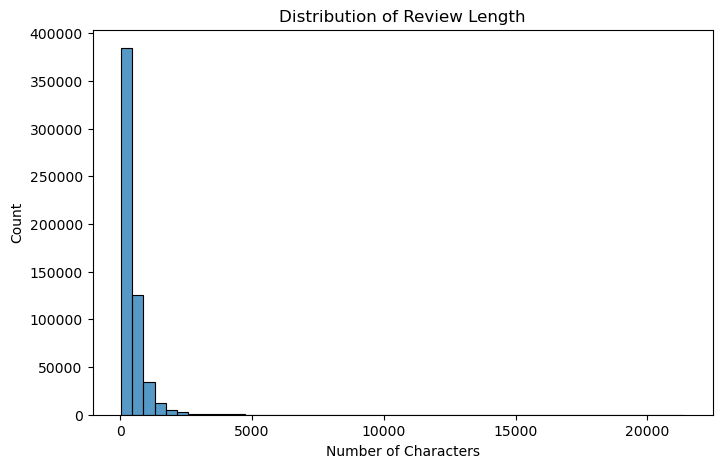

In [8]:
#Length of review distribution
plt.figure(figsize=(8,5))
sns.histplot(df["review_length"], bins=50)
plt.title("Distribution of Review Length")
plt.xlabel("Number of Characters")
plt.ylabel("Count")
plt.savefig("Distribution of reviews")
plt.show()

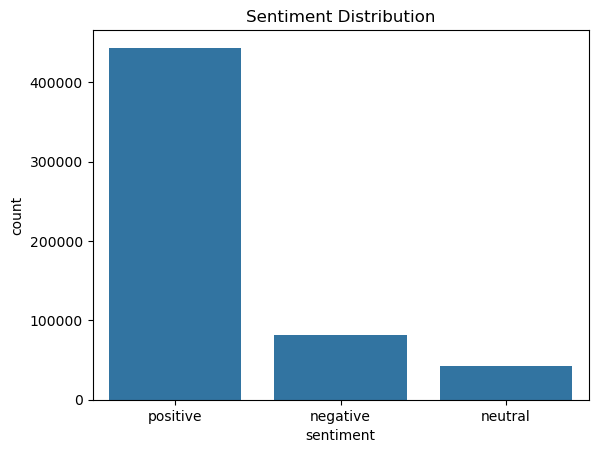

In [7]:
#Visualize the distribution of sentiment lables
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="sentiment", data=df)
plt.title("Sentiment Distribution")
plt.show()

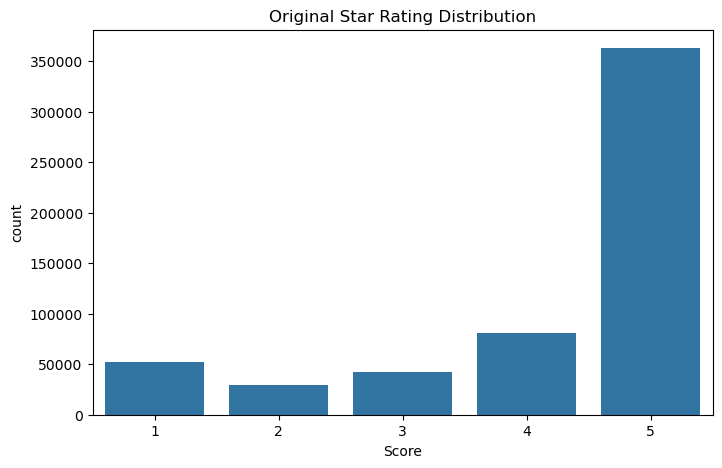

In [9]:
#Star rating distribution
plt.figure(figsize=(8,5))
sns.countplot(x="Score", data=df)
plt.title("Original Star Rating Distribution")
plt.savefig("Original Rating Distribution")
plt.show()

In [10]:
#Example reveiws per class
for sentiment in ["negative", "neutral", "positive"]:
    print(f"\n--- Example {sentiment.upper()} review ---")
    print(df[df["sentiment"] == sentiment]["Text"].iloc[0])


--- Example NEGATIVE review ---
Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".

--- Example NEUTRAL review ---
This seems a little more wholesome than some of the supermarket brands, but it is somewhat mushy and doesn't have quite as much flavor either.  It didn't pass muster with my kids, so I probably won't buy it again.

--- Example POSITIVE review ---
I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.


In [11]:
#Duplicat text
df["Text"].duplicated().sum()

174875